In [119]:
!pip install linearmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, PooledOLS
import warnings
warnings.filterwarnings('ignore')

In [120]:
# Penn World Tables 11.0 — GDP per capita and controls
pwt = pd.read_excel('pwt110.xlsx', sheet_name='Data')

# Target countries and their ISO3 codes
country_map = {
    'PAK': 'Pakistan',
    'IND': 'India',
    'BGD': 'Bangladesh',
    'VNM': 'Vietnam',
    'THA': 'Thailand',
    'MMR': 'Myanmar',
    'JPN': 'Japan',
    'KOR': 'South Korea',
    'NPL': 'Nepal',
    'BTN': 'Bhutan',
    'LKA': 'Sri Lanka',
}
#Filter PWT using our country_map list. We also restrict to years 2000-2020 to match our internet usage data.
pwt_f = pwt[
    (pwt['countrycode'].isin(country_map.keys())) &
    (pwt['year'].between(2000, 2020))
].copy()

# GDP per capita: rgdpe (millions 2017 USD PPP) / pop (millions) = USD PPP per person
pwt_f['gdp_pc']    = pwt_f['rgdpe'] / pwt_f['pop']
pwt_f['ln_gdp_pc'] = np.log(pwt_f['gdp_pc'])

# Trade openness: exports share + abs(imports share)
pwt_f['trade']   = pwt_f['csh_x'] + pwt_f['csh_m'].abs()

# represents the Share of gross capital formation at current Purchasing Power Parities (PPPs)
# capital formation meaning the net increase in phsyical assests plus others.
pwt_f['capform'] = pwt_f['csh_i']

# Keep only relevant columns and rename for merging
pwt_clean = pwt_f[['countrycode','year','ln_gdp_pc','gdp_pc','hc','trade','capform','pop']].copy()
pwt_clean = pwt_clean.rename(columns={'countrycode': 'iso3'})

#make sure it all works
print(f"PWT rows: {len(pwt_clean)}")
print(f"Countries: {pwt_clean['iso3'].nunique()}, Years: {pwt_clean['year'].nunique()}")
print("\nMissing values:")
print(pwt_clean.isnull().sum())
pwt_clean.head()

PWT rows: 231
Countries: 11, Years: 21

Missing values:
iso3          0
year          0
ln_gdp_pc     0
gdp_pc        0
hc           21
trade         0
capform       0
pop           0
dtype: int64


,iso3,year,ln_gdp_pc,gdp_pc,hc,trade,capform,pop
1160,BGD,2000,7.349734,1555.782835,1.639889,0.150221,0.207404,134.544304
1161,BGD,2001,7.358022,1568.730318,1.661910,0.157399,0.210769,136.805810
1162,BGD,2002,7.383912,1609.875489,1.684226,0.160139,0.214708,138.933658
1163,BGD,2003,7.399958,1635.915249,1.706841,0.163637,0.218853,140.970351
1164,BGD,2004,7.417470,1664.815397,1.724663,0.177964,0.227815,142.902856


In [121]:
# Internet CSV loader (WDI wide format only)
YEAR_MIN, YEAR_MAX = 2000, 2020

# Lag-source window: to merge GDP year t with internet year t-1, keep 1999-2019
ITU_LAG_SOURCE_MIN, ITU_LAG_SOURCE_MAX = YEAR_MIN - 1, YEAR_MAX - 1

# Read raw lines first to detect the WDI header row
with open('internet_ds/internet.csv', 'r', encoding='utf-8-sig', errors='replace') as f:
    lines = f.readlines()
# The WDI wide format has a header row containing 'Country Name', 'Country Code', and 'Indicator Code'. 
# We search for this row to determine how many initial rows to skip when loading the CSV with pandas.
header_idx_wdi = next(
    
        i
        for i, line in enumerate(lines)
        if 'Country Name' in line and 'Country Code' in line and 'Indicator Code' in line
    )

# Now we know how many rows to skip, we can load the CSV properly with pandas, ensuring we get the correct header and data.
internet_raw = pd.read_csv(
    'internet_ds/internet.csv',
    encoding='utf-8-sig',
    skiprows=header_idx_wdi
)
internet_raw.columns = internet_raw.columns.str.strip()
# After loading, we check that the required columns are present and identify which columns correspond to years within our lag-source window. 
# filter the data to include only the countries in our country_map.
required_cols = {'Country Code'}
missing_cols = required_cols - set(internet_raw.columns)
# We also identify which columns correspond to years within our lag-source window (1999-2019) to ensure we have the correct data for merging later.
year_cols = [
    c for c in internet_raw.columns
    if str(c).isdigit() and ITU_LAG_SOURCE_MIN <= int(c) <= ITU_LAG_SOURCE_MAX
]
# Create a new df using our country_map list. We also restrict to years 1999-2019 using the year_cols above.
internet = internet_raw[internet_raw['Country Code'].isin(country_map.keys())].copy()
# we melt the data from wide to long format, keeping 'Country Code' as the identifier and transforming the 
# year columns into a single 'year' column with corresponding 'internet_pct' values. 
# We also rename 'Country Code' to 'iso3' for consistency with our PWT data.
internet_clean = internet.melt(
    id_vars=['Country Code'],
    value_vars=year_cols,
    var_name='year',
    value_name='internet_pct',
).rename(columns={'Country Code': 'iso3'})
# Finally, we convert the 'year' column to integers and the 'internet_pct' column to numeric values, coercing any errors to NaN.
internet_clean['year'] = internet_clean['year'].astype(int)
internet_clean['internet_pct'] = pd.to_numeric(internet_clean['internet_pct'], errors='coerce')

# Keep only lag-source years for consistency
internet_clean = internet_clean[internet_clean['year'].between(ITU_LAG_SOURCE_MIN, ITU_LAG_SOURCE_MAX)].copy()

print(f"\nInternet rows: {len(internet_clean)}")
print(f"Countries found: {internet_clean['iso3'].nunique()}")
print(f"ITU source year window (for lagged merge): {internet_clean['year'].min()}-{internet_clean['year'].max()}")
print('Countries:', sorted(internet_clean['iso3'].unique()))
print('\nMissing values:', internet_clean.isnull().sum().to_dict())
internet_clean.head()


Internet rows: 231
Countries found: 11
ITU source year window (for lagged merge): 1999-2019
Countries: ['BGD', 'BTN', 'IND', 'JPN', 'KOR', 'LKA', 'MMR', 'NPL', 'PAK', 'THA', 'VNM']

Missing values: {'iso3': 0, 'year': 0, 'internet_pct': 8}


,iso3,year,internet_pct
0,BGD,1999,0.0362
1,BTN,1999,0.1380
2,IND,1999,0.2730
3,JPN,1999,21.4000
4,KOR,1999,23.6000


In [122]:
# Build explicit lagged ITU series so year t GDP only uses year t-1 internet
internet_lag = internet_clean[['iso3', 'year', 'internet_pct']].copy()
internet_lag['year'] = internet_lag['year'] + 1
internet_lag = internet_lag.rename(columns={'internet_pct': 'internet_lag1'})

# Merge PWT outcome years with lagged ITU years
df = pd.merge(pwt_clean, internet_lag, on=['iso3','year'], how='inner')
df = df[df['year'].between(YEAR_MIN, YEAR_MAX)].copy()

# 3-level development status
developed_isos = ['JPN', 'KOR']
least_developed_isos = ['MMR', 'BGD', 'NPL']
# We create a new 'developed' column that categorizes each country into 'developed', 'developing', or 'least developed' based on their ISO3 codes.
# we add nothing as developing and then filter with our lists above to assign the correct categories. By default, all countries are set to 'developing'.
# it's the dummy variable trap from econometrics 326 
df['developed'] = 'developing'
df.loc[df['iso3'].isin(developed_isos), 'developed'] = 'developed'
df.loc[df['iso3'].isin(least_developed_isos), 'developed'] = 'least developed'
df['developed'] = pd.Categorical(
    df['developed'],
    categories=['least developed', 'developing', 'developed'],
    ordered=True,
)

# Keep indicator variables for the non-reference development groups in regressions
df['is_developed'] = (df['developed'] == 'developed').astype(int)
df['is_least_developed'] = (df['developed'] == 'least developed').astype(int)

# Add country label for plotting
df['country'] = df['iso3'].map(country_map)

# Sort for panel operations
df = df.sort_values(['iso3','year']).reset_index(drop=True)

# Interaction terms: lagged internet x development category
df['internet_x_ldev'] = df['internet_lag1'] * df['is_least_developed']
df['internet_x_devd'] = df['internet_lag1'] * df['is_developed']

print(f"Final dataset: {df.shape[0]} rows, {df['iso3'].nunique()} countries")
print(f"Panel year window: {df['year'].min()}–{df['year'].max()}")
print(f"\nRows per country:")
print(df.groupby('country')['year'].count().sort_values())
print(f"\nDevelopment status by country:")
print(df.groupby(['iso3', 'country'])['developed'].first().sort_values())
print(f"\nMissing values in key variables:")
print(df[['ln_gdp_pc','internet_lag1','hc','trade','capform']].isnull().sum())

Final dataset: 231 rows, 11 countries
Panel year window: 2000–2020

Rows per country:
country
Bangladesh     21
Bhutan         21
India          21
Japan          21
Myanmar        21
Nepal          21
Pakistan       21
South Korea    21
Sri Lanka      21
Thailand       21
Vietnam        21
Name: year, dtype: int64

Development status by country:
iso3  country    
BGD   Bangladesh     least developed
MMR   Myanmar        least developed
NPL   Nepal          least developed
BTN   Bhutan              developing
IND   India               developing
LKA   Sri Lanka           developing
PAK   Pakistan            developing
THA   Thailand            developing
VNM   Vietnam             developing
JPN   Japan                developed
KOR   South Korea          developed
Name: developed, dtype: category
Categories (3, object): ['least developed' < 'developing' < 'developed']

Missing values in key variables:
ln_gdp_pc         0
internet_lag1     8
hc               21
trade             0
capfor

In [123]:

#assing variables and labels for descriptive stats
desc_vars = ['gdp_pc','internet_lag1','hc','trade','capform']
desc_labels = {
    'gdp_pc':       'GDP per Capita (USD PPP)',
    'internet_lag1': 'Internet Usage, lagged 1 year (% population)',
    'hc':           'Human Capital Index',
    'trade':        'Trade Openness (share of GDP)',
    'capform':      'Capital Formation (share of GDP)'
}
# round descriptive stats to 2 decimals and rename index with labels for better readability. Specify the order of the columns to display.
desc = df[desc_vars].describe().T.round(2)
desc.index = [desc_labels[v] for v in desc_vars]
print("=== Descriptive Statistics ===")
print(desc[['count','mean','std','min','25%','50%','75%','max']].to_string())

=== Descriptive Statistics ===
                                              count      mean       std      min      25%      50%       75%       max
GDP per Capita (USD PPP)                      231.0  12879.94  14242.02  1164.89  3691.30  6266.67  13688.24  49920.06
Internet Usage, lagged 1 year (% population)  223.0     25.03     29.04     0.00     1.97    12.74     37.65     96.16
Human Capital Index                           210.0      2.36      0.69     1.37     1.79     2.13      2.89      3.76
Trade Openness (share of GDP)                 231.0      0.31      0.23     0.04     0.14     0.19      0.46      1.05
Capital Formation (share of GDP)              231.0      0.26      0.09     0.10     0.22     0.25      0.30      0.60


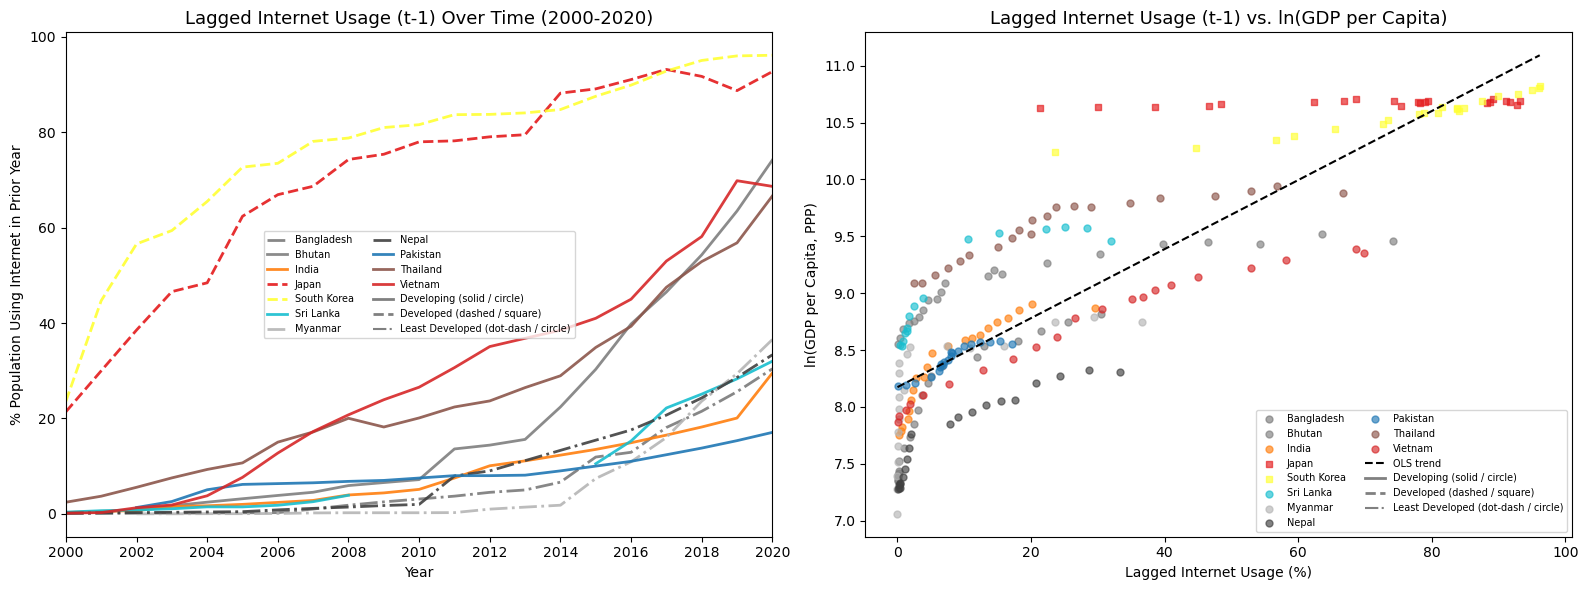

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import numpy as np

# Define country groups used for styling
developed_isos = ['JPN', 'KOR']
least_developed_isos = ['MMR', 'BGD', 'NPL']
developing_isos = [iso for iso in country_map.keys() if iso not in developed_isos + least_developed_isos]

# Build color map by group so style logic is explicit and non-overlapping
dev_colors = cm.tab10(np.linspace(0, 0.95, len(developing_isos)))
devd_colors = cm.Set1(np.linspace(0, 0.6, len(developed_isos)))
ldev_colors = cm.Greys(np.linspace(0.4, 0.8, len(least_developed_isos)))
# Create a master colour map and add developed and least developed colours on top.
# Similar to the df['Developed'] list from earlier
color_map = {iso: dev_colors[i] for i, iso in enumerate(developing_isos)}
color_map.update({iso: devd_colors[i] for i, iso in enumerate(developed_isos)})
color_map.update({iso: ldev_colors[i] for i, iso in enumerate(least_developed_isos)})


# Define line styles and markers by group for visual distinction in plots
style_map = {iso: '-' for iso in developing_isos}
style_map.update({iso: '--' for iso in developed_isos})
style_map.update({iso: '-.' for iso in least_developed_isos})

# Create markers for scatter plot: circles for developing and least developed, squares for developed
marker_map = {iso: 'o' for iso in developing_isos + least_developed_isos}
marker_map.update({iso: 's' for iso in developed_isos})

# initialise figure and axes for the two plots side by side with a specified size of 16 inches wide and 6 inches tall.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Lagged internet usage over time
# cutsomize size, color and style by country group. 
# We loop through each country group and plot their lagged internet usage over time on the first subplot
# alpha is set to 0.9 for better visibility of overlapping lines, and linewidth is set to 2 for clearer lines.
for iso, grp in df.groupby('iso3'):
    axes[0].plot(
        grp['year'], grp['internet_lag1'],
        label=country_map[iso],
        color=color_map.get(iso, 'gray'),
        linestyle=style_map.get(iso, '-'),
        linewidth=2, alpha=0.9
    )
# We set the title and axis labels for the first plot, which shows lagged internet usage over time from 2000 to 2020.
axes[0].set_title('Lagged Internet Usage (t-1) Over Time (2000-2020)', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% Population Using Internet in Prior Year')

# Remove default x padding so the first/last year sit at the chart edge (no visual one-year gap).
x_min, x_max = int(df['year'].min()), int(df['year'].max())
axes[0].set_xlim(x_min, x_max)
axes[0].margins(x=0)
axes[0].set_xticks(np.arange(x_min, x_max + 1, 2))

# Plot 2: Lagged internet vs ln(GDP per Capita) scatter
for iso, grp in df.groupby('iso3'):
    axes[1].scatter(
        grp['internet_lag1'], grp['ln_gdp_pc'],
        label=country_map[iso],
        color=color_map.get(iso, 'gray'),
        marker=marker_map.get(iso, 'o'),
        alpha=0.65, s=25
    )

# Add OLS trend line for overall relationship between lagged internet usage and ln(GDP per Capita). We drop NA values to ensure the regression is based on valid data points.
valid = df[['internet_lag1', 'ln_gdp_pc']].dropna()
m, b = np.polyfit(valid['internet_lag1'], valid['ln_gdp_pc'], 1)
x_line = np.linspace(valid['internet_lag1'].min(), valid['internet_lag1'].max(), 100)
axes[1].plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label='OLS trend')

# We set the title and axis labels for the second plot, which shows the relationship between lagged internet usage and ln(GDP per Capita).
axes[1].set_title('Lagged Internet Usage (t-1) vs. ln(GDP per Capita)', fontsize=13)
axes[1].set_xlabel('Lagged Internet Usage (%)')
axes[1].set_ylabel('ln(GDP per Capita, PPP)')

# Add per-country legend entries plus style convention entries
convention_handles = [
    Line2D([0], [0], color='gray', linestyle='-', lw=2, label='Developing (solid / circle)'),
    Line2D([0], [0], color='gray', linestyle='--', lw=2, label='Developed (dashed / square)'),
    Line2D([0], [0], color='gray', linestyle='-.', lw=1.5, label='Least Developed (dot-dash / circle)'),
]

# We loop through each axis and add a legend that combines the individual country entries with the convention entries for line styles and markers.
#  The legend is placed in the 'best' location to avoid overlapping with data points,
#  and the font size is set to 7 with 2 columns for better readability.
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles + convention_handles,
        labels + [h.get_label() for h in convention_handles],
        fontsize=7, ncol=2, loc='best'
    )
# use tight_layout to optimize spacing between subplots and save the figure as a PNG file
#  with a specified resolution of 150 DPI and tight bounding box to minimize whitespace around the image. 
# Finally, we display the plot.
plt.tight_layout()
plt.savefig('eda_internet_gdp.png', dpi=150, bbox_inches='tight')
plt.show()

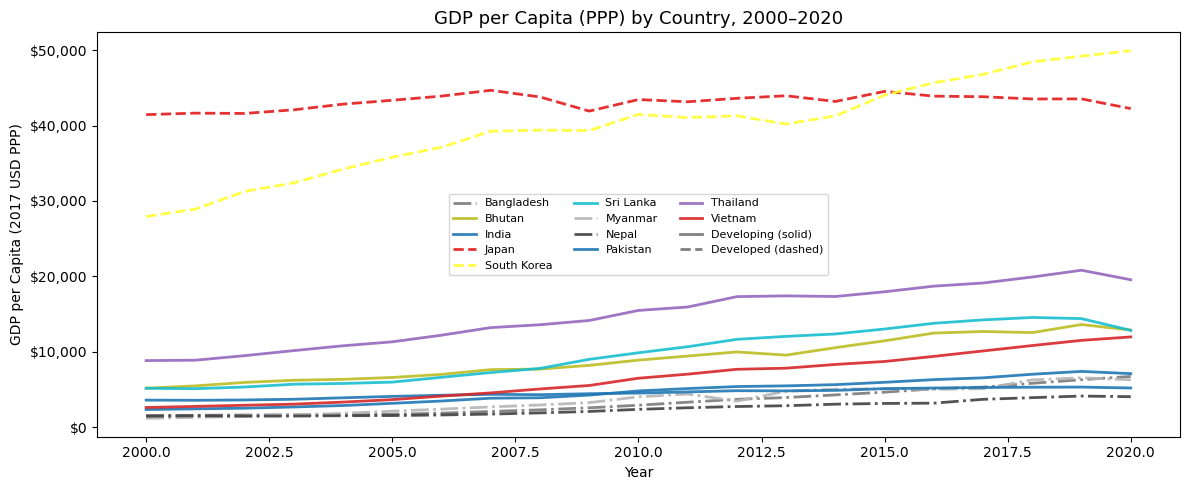

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
# Same as before, we loop through each country group and plot their GDP per capita over time on a single subplot, 
# customizing the size, color, and style by country group for visual distinction.
for iso, grp in df.groupby('iso3'):
    ax.plot(grp['year'], grp['gdp_pc'],
            label=country_map[iso],
            color=color_map[iso],
            linestyle=style_map[iso],
            linewidth=2, alpha=0.9)
# setting titles, lables, and formatting the y-axis to display GDP per capita in a more readable format with dollar signs and commas for thousands separators.
ax.set_title('GDP per Capita (PPP) by Country, 2000–2020', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (2017 USD PPP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=8, ncol=3)

# We add custom legend entries to explain the line styles for developing vs developed countries.
legend_elements = [
    Line2D([0],[0], color='gray', linestyle='-',  lw=2, label='Developing (solid)'),
    Line2D([0],[0], color='gray', linestyle='--', lw=2, label='Developed (dashed)')
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_elements,
          labels=labels + ['Developing (solid)', 'Developed (dashed)'],
          fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig('gdp_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [126]:
# Drop rows missing any key variable
reg_vars = ['ln_gdp_pc','internet_lag1','hc','trade','capform','developed','internet_x_devd']
df_reg = df.dropna(subset=reg_vars).copy()

# Set MultiIndex required by linearmodels (entity, time)
df_reg = df_reg.set_index(['iso3','year'])

print(f"Regression sample: {len(df_reg)} obs, {df_reg.index.get_level_values('iso3').nunique()} countries")
print(f"Year range: {df_reg.index.get_level_values('year').min()}–{df_reg.index.get_level_values('year').max()}")

Regression sample: 202 obs, 10 countries
Year range: 2000–2020


In [ ]:
# Pooled OLS ignores panel structure — useful as a naive baseline
X_pool = sm.add_constant(df_reg[['internet_lag1','hc','trade','capform']])
pooled = PooledOLS(df_reg['ln_gdp_pc'], X_pool).fit(cov_type='robust')
# to format nicely
print("=" * 60)
print("MODEL 1: POOLED OLS (Baseline — no fixed effects)")
print("=" * 60)
print(pooled.summary)

MODEL 1: POOLED OLS (Baseline — no fixed effects)
                          PooledOLS Estimation Summary                          
Dep. Variable:              ln_gdp_pc   R-squared:                        0.9106
Estimator:                  PooledOLS   R-squared (Between):              0.9453
No. Observations:                 202   R-squared (Within):               0.6240
Date:                Tue, Apr 07 2026   R-squared (Overall):              0.9106
Time:                        17:42:13   Log-likelihood                   -56.254
Cov. Estimator:                Robust                                           
                                        F-statistic:                      501.73
Entities:                          10   P-value                           0.0000
Avg Obs:                       20.200   Distribution:                   F(4,197)
Min Obs:                       15.000                                           
Max Obs:                       21.000   F-statistic (robust

In [ ]:
# Country FE (absorbs geography, institutions) + Year FE (absorbs global shocks)
fe_main = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1','hc','trade','capform']],
    entity_effects=True,
    time_effects=True
).fit(cov_type='clustered', cluster_entity=True)  # Cluster SEs by country

print("=" * 60)
print("MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)")
print("Clustered SEs by country")
print("=" * 60)
print(fe_main.summary)

MODEL 2: TWO-WAY FIXED EFFECTS (Country + Year FEs)
Clustered SEs by country
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.5026
Estimator:                   PanelOLS   R-squared (Between):              0.6730
No. Observations:                 202   R-squared (Within):               0.6989
Date:                Tue, Apr 07 2026   R-squared (Overall):              0.6716
Time:                        17:42:13   Log-likelihood                    137.86
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      42.438
Entities:                          10   P-value                           0.0000
Avg Obs:                       20.200   Distribution:                   F(4,168)
Min Obs:                       15.000                                           
Max Obs:                       2

In [129]:
# MODEL 3: FE with three-category development interaction
# NOTE: time-invariant development dummies are absorbed by country fixed effects.
# The interaction terms use developing as the reference category.

fe_interact = PanelOLS(
    df_reg['ln_gdp_pc'],
    df_reg[['internet_lag1', 'internet_x_ldev', 'internet_x_devd', 'hc', 'trade', 'capform']],
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True      # Silently drops any remaining collinear variables
).fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3: FE WITH THREE-CATEGORY DEVELOPMENT INTERACTION")
print("(Development dummies absorbed by country FEs; developing is the reference)")
print("=" * 60)
print(fe_interact.summary)

# Interpret coefficients
b1  = fe_interact.params['internet_lag1']
b2  = fe_interact.params['internet_x_ldev']
b3  = fe_interact.params['internet_x_devd']
se1 = fe_interact.std_errors['internet_lag1']
se2 = fe_interact.std_errors['internet_x_ldev']
se3 = fe_interact.std_errors['internet_x_devd']

print("\n--- Interpretation ---")
print(f"Effect for DEVELOPING countries (β₁):             {b1:.5f}  (SE: {se1:.5f})")
print(f"Additional effect for LEAST DEVELOPED (β₂):       {b2:.5f}  (SE: {se2:.5f})")
print(f"Additional effect for DEVELOPED (β₃):             {b3:.5f}  (SE: {se3:.5f})")
print(f"Total effect for LEAST DEVELOPED (β₁ + β₂):       {b1 + b2:.5f}")
print(f"Total effect for DEVELOPED (β₁ + β₃):             {b1 + b3:.5f}")
print(f"\nA 1 pp rise in internet usage is associated with:")
print(f"  Developing:      {b1*100:.3f}% change in GDP per capita")
print(f"  Least developed: {(b1 + b2)*100:.3f}% change in GDP per capita")
print(f"  Developed:       {(b1 + b3)*100:.3f}% change in GDP per capita")

MODEL 3: FE WITH THREE-CATEGORY DEVELOPMENT INTERACTION
(Development dummies absorbed by country FEs; developing is the reference)
                          PanelOLS Estimation Summary                           
Dep. Variable:              ln_gdp_pc   R-squared:                        0.7429
Estimator:                   PanelOLS   R-squared (Between):              0.4021
No. Observations:                 202   R-squared (Within):               0.7128
Date:                Tue, Apr 07 2026   R-squared (Overall):              0.4013
Time:                        17:42:13   Log-likelihood                    204.50
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      79.938
Entities:                          10   P-value                           0.0000
Avg Obs:                       20.200   Distribution:                   F(6,166)
Min Obs:                       15.000                      

In [ ]:
# We create a summary table of the key regression results, 
# including the coefficients for the main variable of interest (lagged internet usage) and 
# the interaction terms with development status, as well as the control variables.
def fmt(params, pvalues, key):
    """Format coefficient with significance star, or return '—' if not in model."""
    if key not in params:
        return '—'
    stars = '*' * int(pvalues[key] < 0.05)
    return f"{params[key]:.4f}{stars}"
# We construct a dictionary to hold the formatted results for each variable and model.
results_data = {
    'Variable': [
        'Internet (lag 1)', 'Internet × Least Developed', 'Internet × Developed',
        'Human Capital', 'Trade Openness', 'Capital Formation'
    ],# We format the coefficients and significance stars for each variable across the three models, using the fmt function defined above.
    'Pooled OLS': [
        fmt(pooled.params, pooled.pvalues, 'internet_lag1'),
        '—',
        '—',
        fmt(pooled.params, pooled.pvalues, 'hc'),
        fmt(pooled.params, pooled.pvalues, 'trade'),
        fmt(pooled.params, pooled.pvalues, 'capform'),
    ],
    'Two-Way FE': [
        fmt(fe_main.params, fe_main.pvalues, 'internet_lag1'),
        '—',
        '—',
        fmt(fe_main.params, fe_main.pvalues, 'hc'),
        fmt(fe_main.params, fe_main.pvalues, 'trade'),
        fmt(fe_main.params, fe_main.pvalues, 'capform'),
    ],
    'FE + Interaction': [
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_lag1'),
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_x_ldev'),
        fmt(fe_interact.params, fe_interact.pvalues, 'internet_x_devd'),
        fmt(fe_interact.params, fe_interact.pvalues, 'hc'),
        fmt(fe_interact.params, fe_interact.pvalues, 'trade'),
        fmt(fe_interact.params, fe_interact.pvalues, 'capform')
    ]
}

results_df = pd.DataFrame(results_data)
print("=== REGRESSION RESULTS SUMMARY ===")
print("Dependent variable: ln(GDP per Capita, PPP)")
print("Reference category for development interactions: developing")
print("* = significant at 5% level")
print()
print(results_df.to_string(index=False))
results_df.to_csv('regression_results.csv', index=False)
print("\nSaved to regression_results.csv")

=== REGRESSION RESULTS SUMMARY ===
Dependent variable: ln(GDP per Capita, PPP)
Reference category for development interactions: developing
* = significant at 5% level

                  Variable Pooled OLS Two-Way FE FE + Interaction
          Internet (lag 1)    0.0091*    -0.0008          0.0076*
Internet × Least Developed          —          —          0.0074*
      Internet × Developed          —          —         -0.0130*
             Human Capital    1.1196*    1.2896*           0.5876
            Trade Openness     0.1524    -0.4209          -0.1742
         Capital Formation    -0.4578    3.7043*          2.7442*

Saved to regression_results.csv
